# Board game recommender demo

Free text in, one game and a reason out. Requests the rules can read in full never leave the machine. Everything else goes to Groq when `LLM_API_KEY` is set, and is asked back otherwise.

In [1]:
from board_game_reco import Recommender
recommender = Recommender.default()
print('cloud model configured:', recommender.llm is not None)

cloud model configured: False


In [2]:
queries = [
    'family game for 4, not too complicated',
    'something similar to Catan but shorter',
    'games by Uwe Rosenberg for 2',
    'a relaxing nature game',
    'a game for 12 players in 5 minutes',
    'a game for 4 that takes 3 turns',
    'อยากได้เกมเล่น 4 คน ไม่เกินหนึ่งชั่วโมง',
    'what is the capital of France',
]
for q in queries:
    r = recommender.recommend(q)
    print('>', q)
    print('  pick:', r.game.name if r.game else '(none)', '| engine:', r.engine)
    print('  reason:', r.reason or '-')
    if r.follow_up:
        print('  follow-up:', r.follow_up)
    print('  trace:', r.trace)


> family game for 4, not too complicated
  pick: Dream Home | engine: rules
  reason: Dream Home (2016) plays 2-4 players in about 30 minutes. Ages 7+, weight 1.7 out of 5, rated 6.9 by 7,598 people. It is the closest match to what you described. BGG ranks it as a family game. It edged out CoraQuest mainly on how closely it matches what you asked for. https://boardgamegeek.com/boardgame/194880/dream-home
  trace: {'catalog': 2000, 'eligible': 1717, 'removed': {'players': 283, 'max_minutes': 0, 'youngest_age': 0}, 'engine': 'rules', 'scored': 1717, 'picked': 1}
> something similar to Catan but shorter
  pick: The Isle of Cats | engine: rules
  reason: The Isle of Cats (2019) plays 1-4 players in about 90 minutes. Ages 8+, weight 2.4 out of 5, rated 7.6 by 24,026 people. It is the closest match to CATAN outside its family. It edged out Mombasa mainly on how closely it matches what you asked for. https://boardgamegeek.com/boardgame/281259/the-isle-of-cats
  trace: {'catalog': 2000, 'eligi

## Why this game

Score terms for one pick. Every weight lives in `Weights`.

In [3]:
r = recommender.recommend('a cooperative game for 2, not too complicated')
print(r.game.name)
for term, value in sorted(r.terms.items(), key=lambda kv: -kv[1]):
    print(f'{term:12s} {value:+.3f}')
print('runners-up:', [g.name for g in r.runners_up])

Décorum
similarity   +0.909
coop         +0.300
weight_band  +0.294
rating       +0.172
runners-up: ['The Fellowship of the Ring: Trick-Taking Game', 'ito']


## Routing evidence

The route ROC from the latest `python -m evals.run route`. The threshold in `intent.py` was picked on the dev split.

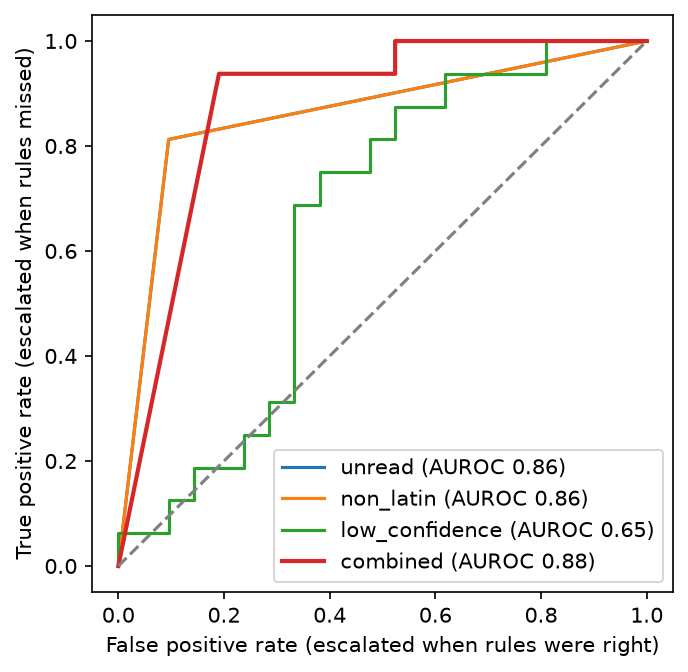

In [4]:
from pathlib import Path
from IPython.display import Image
latest = sorted(Path('../evals/results').glob('*/route_roc.png'))[-1]
Image(filename=str(latest))